# Phase 1: Best Algorithm Inspection & Gallery
Inspect and compare the top algorithms produced by each model.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
import difflib
import textwrap
from IPython.display import Markdown, display

plt.rcParams.update({"figure.figsize": (12, 6), "font.size": 11})

# --- Constants ---
RESULTS_DIR = Path("../results_phase1")
MODELS = [
    "qwen3.5-4b", "qwen3.5-9b", "qwen3.5-27b",
    "rnj-1-8b", "devstral-small-2-24b",
    "olmo3-7b", "olmo3-32b",
    "granite4-3b",
    "gemini-3-pro", "gemini-3-flash",
]
N_SEEDS = 5
BUDGET = 100
N_INSTANCES = 10
EVAL_SEEDS = 5


def parse_fitness(val):
    try:
        return float(val)
    except (TypeError, ValueError):
        return float("-inf")


def load_run(run_dir: Path):
    """Load all entries from a run's log.jsonl."""
    log_file = run_dir / "log.jsonl"
    if not log_file.exists():
        return []
    entries = []
    with open(log_file) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            entries.append(json.loads(line))
    return entries


# --- Load best algorithms ---
best_per_model = {}   # model -> dict with best candidate info
all_best = []         # list of dicts for statistical comparison

for model in MODELS:
    model_dir = RESULTS_DIR / model
    if not model_dir.exists():
        print(f"WARNING: {model_dir} not found, skipping.")
        continue

    seed_bests = []  # (seed, best_entry, best_fitness, aucs)
    for seed in range(N_SEEDS):
        seed_dir = model_dir / f"seed-{seed}"
        if not seed_dir.exists():
            continue
        run_dirs = sorted(seed_dir.glob("run-*"))
        if not run_dirs:
            continue
        # Use the last (or only) run directory
        entries = load_run(run_dirs[-1])
        if not entries:
            continue
        # Find best entry in this seed
        best_entry = None
        best_fit = float("-inf")
        for e in entries:
            f = parse_fitness(e.get("fitness"))
            if f > best_fit:
                best_fit = f
                best_entry = e
        if best_entry is not None:
            aucs = best_entry.get("metadata", {}).get("aucs", [])
            seed_bests.append((seed, best_entry, best_fit, aucs))
            all_best.append({
                "model": model,
                "seed": seed,
                "fitness": best_fit,
                "name": best_entry.get("name", "?"),
                "aucs": aucs,
            })

    if not seed_bests:
        continue

    # Pick the seed with the highest best AOCC
    seed_bests.sort(key=lambda x: x[2], reverse=True)
    best_seed, best_entry, best_fit, aucs = seed_bests[0]
    aucs_arr = np.array(aucs) if aucs else np.array([])
    best_per_model[model] = {
        "seed": best_seed,
        "fitness": best_fit,
        "name": best_entry.get("name", "?"),
        "code": best_entry.get("code", ""),
        "aucs": aucs_arr,
        "mean_aocc": float(np.mean(aucs_arr)) if len(aucs_arr) > 0 else float("-inf"),
        "std_aocc": float(np.std(aucs_arr)) if len(aucs_arr) > 0 else 0.0,
    }

# --- Summary table ---
rows = []
for model in MODELS:
    if model not in best_per_model:
        continue
    info = best_per_model[model]
    rows.append({
        "Model": model,
        "Algorithm": info["name"],
        "Best AOCC (mean +/- std)": f"{info['mean_aocc']:.4f} +/- {info['std_aocc']:.4f}",
        "Seed": info["seed"],
    })

df_summary = pd.DataFrame(rows)
display(df_summary)

# --- Display code for each model's best algorithm ---
for model in MODELS:
    if model not in best_per_model:
        continue
    info = best_per_model[model]
    md = f"### {model} — {info['name']} (AOCC={info['mean_aocc']:.4f}, seed={info['seed']})\n\n"
    md += f"```python\n{info['code']}\n```\n"
    display(Markdown(md))

,Model,Algorithm,Best AOCC (mean +/- std),Seed
0,qwen3.5-4b,AdaptiveDifferentialEvolutionOptimizer,0.7787 +/- 0.1350,3
1,qwen3.5-9b,StochasticGradientMomentumSearch,0.5202 +/- 0.3052,2
2,qwen3.5-27b,RobustArchiveDifferentialEvolution,0.8292 +/- 0.1499,2
3,rnj-1-8b,AdaptiveRandomSearch,0.3188 +/- 0.0669,0
4,devstral-small-2-24b,ADE_LS,0.8485 +/- 0.1222,0
5,olmo3-7b,EnhancedDEWithProximitySearch,0.8169 +/- 0.1543,4
6,olmo3-32b,AdaptiveLocalCEM,0.7957 +/- 0.1714,1
7,granite4-3b,AdaptiveDifferentialEvolutionDynamicSampling,0.6832 +/- 0.1113,0
8,gemini-3-pro,FDBActiveBIPOPCMAES,0.8980 +/- 0.1847,2
9,gemini-3-flash,BIP_AMOS_NES,0.9227 +/- 0.0889,3


### qwen3.5-4b — AdaptiveDifferentialEvolutionOptimizer (AOCC=0.7787, seed=3)

```python
import numpy as np

class AdaptiveDifferentialEvolutionOptimizer:
    def __init__(self, budget, dim):
        self.budget = budget
        self.dim = dim
        # Search space bounds
        self.bounds_low = -5.0
        self.bounds_high = 5.0
        
        # Initial DE parameters (tuned for BBOB average difficulty)
        self.F = 0.8 
        self.CR = 0.9
        self.pop_size = max(5, min(int(budget / dim), 20))
        
        self.X = np.random.uniform(self.bounds_low, self.bounds_high, (self.pop_size, self.dim))
        # Store initial fitnesses
        self.Fitness = np.full(self.pop_size, np.inf)
        
        # Best solution found so far
        self.f_opt = self.Fitness[0]
        self.x_opt = self.X[0].copy()

        # Budget tracking
        self.current_budget_used = 0
        
        # Adaptation and Stagnation Parameters
        self.stagnation_counter = 0
        self.max_stagnation = int(budget * 0.1) # Restart if no improvement for 10% of budget
        self.adapt_period = max(1, int(budget / (self.dim * 2)))
        
    def __call__(self, func):
        self.current_budget_used += self.pop_size
        for i in range(self.pop_size):
            val = func(self.X[i])
            self.Fitness[i] = val
            if val < self.f_opt:
                self.f_opt = val
                self.x_opt = self.X[i].copy()
                
        while self.current_budget_used < self.budget:
            # Check for stagnation every 5 generations (or per iteration step)
            # Here we use a simpler loop structure: 
            # We simulate 'generations' but ensure budget safety.
            
            # Stagnation check logic: if best hasn't changed in X steps
            # Since we iterate through population, let's track progress
            improved_last_iter = False
            
            for trial_idx in range(self.pop_size):
                if self.current_budget_used >= self.budget:
                    break
                
                # Mutation (DE/jDE strategy variant)
                # Select three distinct indices from the population
                r1 = np.random.randint(0, self.pop_size)
                r2 = np.random.randint(0, self.pop_size)
                r3 = np.random.randint(0, self.pop_size)
                
                while r1 == r2 or r2 == r3:
                    if r1 == r2: r2 = np.random.randint(0, self.pop_size)
                    else: r3 = np.random.randint(0, self.pop_size)
                
                # Use global best for better exploration direction sometimes? 
                # Standard DE uses population indices. We stick to population indices but use F adaptively.
                x_new = self.X[r1] + self.F * (self.X[r2] - self.X[r3])

                # Boundary Handling: Bounce strategy is often superior for maintaining diversity
                def bounce(a, b):
                    if a < b:
                        return b - (b - a)  # Reflect off left/bound? 
                    else:
                        return b + (a - b)
                
                x_new = np.clip(x_new, self.bounds_low, self.bounds_high)

                # Crossover (Binomial Strategy)
                trial_candidate = self.X[trial_idx].copy()
                for j in range(self.dim):
                    if np.random.uniform() < self.CR:
                        trial_candidate[j] = x_new[j]

                # Evaluate Candidate
                val_trial = func(trial_candidate)
                
                self.current_budget_used += 1
                
                # Selection Logic: Survival of the Fittest (Standard DE)
                # Keep the one with lower function value.
                if val_trial < self.Fitness[trial_idx]:
                    self.X[trial_idx] = trial_candidate
                    self.Fitness[trial_idx] = val_trial
                    improved_last_iter = True
                
                # Update Global Best if it's a better solution found during this sweep
                if val_trial < self.f_opt:
                    self.f_opt = val_trial
                    self.x_opt = trial_candidate.copy()

            # Adaptive Strategy for F and CR after every generation (or fixed step)
            # We can implement adaptation based on improvement rate
            
            # Check stagnation based on global best value changes
            # For simplicity in budget loop: if we haven't improved f_opt significantly in recent passes...
            # Since this loop is tight per budget, we count improvements to best_f_opt
            self.current_budget_used += 1 # Just one check
        return self.f_opt, self.x_opt
```


### qwen3.5-9b — StochasticGradientMomentumSearch (AOCC=0.5202, seed=2)

```python
import numpy as np

class StochasticGradientMomentumSearch:
    def __init__(self, budget, dim):
        self.budget = budget
        self.dim = dim
        self.f_opt = np.inf
        self.x_opt = None
        # History buffer (e.g., 5 points for gradient approximation)
        self.history_len = 5
        self.history = [] # List of tuples (x, f, mu) # mu could be momentum
        
        # Control parameters
        self.initial_step = 2.0 / dim * 2
        self.decay_rate = 0.98
        self.momentum = 0.1 # Coefficient for momentum decay
        self.momentum_update = 0.5
        
        self.eval_cnt = 0

    def _estimate_gradient(self):
        # Very simplified gradient estimation: difference between last 2 successful
        # If history < 2, return all-zeros
        if len(self.history) < 2:
            return np.zeros(self.dim)
            
        # Sort history by fitness (best last)
        # We want direction of improvement. 
        # Let's just take diff between 2 best stored points
        x1 = self.history[-1][0]
        x2 = self.history[-2][0]
        f1 = self.history[-1][1]
        f2 = self.history[-2][1]
        
        # Simple difference vector as proxy
        return x1 - x2

    def __call__(self, func):
        self.history = []
        self.eval_cnt = 0
        
        # Initialize with random point
        x = np.random.uniform(-5.0, 5.0, self.dim)
        f = func(x)
        
        if f > self.f_opt:
             self.f_opt = f
             self.x_opt = x.copy()
        
        # Add to history
        self.history.append((x, f))
        self.eval_cnt = 1
        
        if self.budget == 0:
            return f, x.copy()
            
        # Momentum vector from best history
        momentum_vec = np.zeros(self.dim)
        last_mom_step = np.zeros(self.dim)
        step_magnitude = np.inf # To track deleterious moves
        
        best_x = x.copy()
        best_f = f
        
        # Loop
        while self.eval_cnt < self.budget:
            remaining = self.budget - self.eval_cnt
            if remaining <= 0: break

            # Strategy:
            # 1. Try to use gradient estimate to move best x.
            # 2. Add stochastic noise for exploration.
            # 3. Scale gravity based on improvement.
            
            # Estimate displacement from history
            # Use history[-2] and history[-1] to see where we came from
            if len(self.history) > 3:
                x_rest = self.history[-4][0]
                x_curr = self.history[-3][0]
                # Midpoint logic? No, just diff
                try_vec = (self.history[-1][0] + self.history[-3][0]) / 2 - self.history[-2][0] # Local diffs
                try_vec += (x_curr - self.history[-1][0]) * 0.5 # Center spread
                
                # Let's simplify: Random perturbation + Gradient approximation
                # We need a candidate
                delta = np.random.randn(self.dim) * (self.initial_step * np.exp(-0.05 * self.eval_cnt))
                
                # Add momentum based on best history direction
                if len(self.history) >= 2:
                   # Direction from 2nd to 1st best in history
                   v_hist = self.history[-1][0] - self.history[-2][0]
                   # If going downhill, follow v_hist.
                   # Only accumulate if delta was good (implicit)
                   
            # Let's use a clearer logic:
            # Candidate = Best + (Random * Sigma) + (Momentum * V_hist)
            
            # Simplified Momentum Logic
            sigma = self.initial_step * np.exp(-0.02 * self.eval_cnt) * self.dim # Scaling
            noise = np.random.randn(self.dim) * sigma
            
            # Momentum term derived from last successful update
            # If we haven't had a successful update recently (length of history > 1 implies we made updates)
            # Actually just use history[-1] - history[-2]
            if len(self.history) >= 2:
                vel_est = best_x - self.history[-2][0] # (Current best - prev best)
                # This points where we went.
                momentum = vel_est * self.initial_step
            else:
                momentum = np.zeros(self.dim)
            
            # Combine Noise and Momentum (if momentum helped make last step)
            if f < best_f: # We are improving
                # Activate momentum
                candidate = best_x + momentum - 0.1*np.random.randn(self.dim) # Mix
            else:
                # No improvement: Momentum is bad, rely on noise
                candidate = best_x + noise
                
            candidate = np.clip(candidate, -5.0, 5.0)
            
            f_cand = func(candidate)
            self.eval_cnt += 1
            
            if f_cand < best_f:
                best_f = f_cand
                best_x = candidate.copy()
                self.f_opt = best_f
                self.x_opt = best_x
                # Update history
                self.history.append((best_x, best_f))
                if len(self.history) > self.history_len:
                    self.history.pop(0)
            else:
                # Stagnation / spread history
                self.history.append((candidate, f_cand))
                if len(self.history) > self.history_len:
                    self.history.pop(0)

        return self.f_opt, self.x_opt.copy()
```


### qwen3.5-27b — RobustArchiveDifferentialEvolution (AOCC=0.8292, seed=2)

```python
import numpy as np

class RobustArchiveDifferentialEvolution:
    def __init__(self, budget, dim):
        self.budget = budget
        self.dim = dim
        self.lower_bound = -5.0
        self.upper_bound = 5.0
        
        # Dynamic Population Sizing: Balances diversity (4*dim) with budget constraints (min 20 gens)
        target_np = max(20, int(4 * dim))
        min_generations = 20
        max_possible_np = self.budget // max(min_generations, 1)
        
        self.population_size = min(target_np, max_possible_np) 
        # Ensure minimum size for mutation strategies (needs at least 3 distinct individuals)
        if self.population_size < 4: 
            self.population_size = max(4, int(self.budget / 2))

        # Optimization run state will be reset in __call__
        
    def __call__(self, func):
        # Reset State for Run
        self.evaluations_used = 0
        self.global_best_f = np.inf
        self.global_best_x = None
        
        # External Archive (L-SHADE style) for diversity maintenance
        self.archive = [] 
        self.archive_max_size = self.population_size
        
        # Success History for Parameter Adaptation (F, CR)
        self.history_window = 30 
        self.success_f = []
        self.success_cr = []
        
        # Strategy Weights: [rand/1, pbest/1, current-to-pbest/1]
        self.strategy_weights = np.array([0.4, 0.3, 0.3]) 
        
        # Stagnation Tracking
        self.evals_since_best = 0
        self.stagnation_limit = max(50, int(self.budget / (10 * self.dim)))

        # Initialization via Latin Hypercube Sampling for broad coverage
        population = self._lhs_init(self.population_size, self.dim)
        fitness = np.full(self.population_size, np.inf)
        
        # Initial Evaluation
        for i in range(self.population_size):
            if self.evaluations_used >= self.budget:
                break
            f_val = func(population[i])
            fitness[i] = f_val
            self.evaluations_used += 1
            
            if f_val < self.global_best_f:
                self.global_best_f = f_val
                self.global_best_x = population[i].copy()
                self.evals_since_best = 0
        
        # Optimization Loop
        while self.evaluations_used < self.budget:
            generation_evals = 0
            
            # Calculate Population Diversity (Fitness Range) to adapt strategy bias
            current_diversity = np.max(fitness) - np.min(fitness)
            
            for i in range(self.population_size):
                if self.evaluations_used >= self.budget:
                    break
                
                # Adaptive Parameter Generation based on Success History
                F, CR = self._get_adaptive_params(current_diversity)
                
                # Strategy Selection influenced by Diversity and Weights
                strategy_idx = self._select_strategy(current_diversity)
                
                # Create Trial Vector with Archive Support
                trial = self._create_trial(population, fitness, i, F, CR, strategy_idx)
                trial = self._repair_boundaries(trial)
                
                # Evaluate Trial
                f_trial = func(trial)
                self.evaluations_used += 1
                generation_evals += 1
                
                # Selection Mechanism (Tournament against Target)
                if f_trial < fitness[i]:
                    # Trial wins: Keep Trial, Archive the Old Parent
                    population[i] = trial.copy()
                    fitness[i] = f_trial
                    
                    # Add old parent to archive for diversity in future mutations
                    self._manage_archive(population[i].copy()) 
                    
                    if f_trial < self.global_best_f:
                        self.global_best_f = f_trial
                        self.global_best_x = trial.copy()
                        self.evals_since_best = 0
                        
                        # Record Success
                        self._record_success(F, CR, strategy_idx)
                        
                else:
                    # Parent wins: Keep Parent, Archive the Failed Trial
                    self._manage_archive(trial)
                    self.evals_since_best += 1
            
            # Stagnation Recovery Check
            if self.evals_since_best > self.stagnation_limit:
                self._handle_stagnation(population, fitness, func)
                self.evals_since_best = 0

        return self.global_best_f, self.global_best_x
    
    def _lhs_init(self, size, dim):
        pop = np.empty((size, dim))
        for d in range(dim):
            bounds = np.linspace(0, 1, size + 1)
            points = np.random.uniform(bounds[:-1], bounds[1:])
            shuffled = np.random.permutation(points)
            pop[:, d] = self.lower_bound + (self.upper_bound - self.lower_bound) * shuffled
        return pop

    def _manage_archive(self, candidate):
        if len(self.archive) < self.archive_max_size:
            self.archive.append(candidate.copy())
        else:
            # Replace random archive entry to maintain freshness
            idx = np.random.randint(len(self.archive))
            self.archive[idx] = candidate.copy()

    def _select_strategy(self, diversity):
        probs = self.strategy_weights.copy()
        # If diversity is low, favor exploitation (current-to-pbest)
        if diversity < 0.5: 
            probs[2] += 0.3 
        elif diversity > 2.0: # If high, favor exploration (rand/1)
            probs[0] += 0.3
            
        total = sum(probs)
        if total == 0: return np.random.randint(3)
        probs = probs / total
        
        return np.random.choice(3, p=probs)

    def _get_adaptive_params(self, diversity):
        # Initialize with exploration bias if history is short
        if len(self.success_f) < 10:
            F = max(0.5, min(1.0, np.random.laplace(0.8, 0.4))) 
            CR = np.random.uniform(0.3, 0.8)
            return F, CR
            
        # Adaptive Sampling from Success History (SHADE style)
        recent_F = self.success_f[-self.history_window:]
        recent_CR = self.success_cr[-self.history_window:]
        
        mu_F = np.mean(recent_F)
        mu_CR = np.mean(recent_CR)
        
        # Adjust F variance based on diversity: Low diversity -> Smaller steps (Exploit)
        if diversity < 1.0: 
            std_F_scale = 0.15
        else: 
            std_F_scale = 0.35

        F = max(0, min(1.0, mu_F + np.random.laplace(0, std_F_scale))) 
        CR = max(0, min(1.0, mu_CR + np.random.normal(0, 0.05)))

        return F, CR

    def _record_success(self, F, CR, strategy_idx):
        self.success_f.append(F)
        self.success_cr.append(CR)
        
        if len(self.success_f) > self.history_window:
            self.success_f = self.success_f[-self.history_window:]
            self.success_cr = self.success_cr[-self.history_window:]

    def _create_trial(self, population, fitness, target_idx, F, CR, strategy):
        dim = self.dim
        pop_size = len(population)
        
        # Identify top individuals for P-Best strategies
        k = max(1, int(pop_size * 0.2))
        best_indices = np.argsort(fitness)[:k]
        
        if strategy == 0: 
            # DE/rand/1 with Archive Injection for Exploration
            candidates = [j for j in range(pop_size) if j != target_idx]
            idx_r1, idx_r2 = np.random.choice(candidates, 2, replace=False)
            
            # Use archive vector to increase diversity in mutation
            if self.archive and np.random.random() < 0.5:
                vec_archive = self.archive[np.random.randint(len(self.archive))]
                mutant = population[idx_r1] + F * (population[idx_r2] - vec_archive)
            else:
                candidates_rem = [j for j in candidates if j not in (idx_r1, idx_r2)]
                if not candidates_rem: candidates_rem = candidates
                idx_r3 = np.random.choice(candidates_rem, 1)[0]
                mutant = population[idx_r1] + F * (population[idx_r2] - population[idx_r3])
                
        elif strategy == 1:
            # DE/pbest/1
            r_best = best_indices[np.random.randint(len(best_indices))]
            candidates = [j for j in range(pop_size) if j != target_idx and j != r_best]
            idx_r2, idx_r3 = np.random.choice(candidates, 2, replace=False)
            mutant = population[r_best] + F * (population[idx_r2] - population[idx_r3])
            
        else:
            # DE/current-to-pbest/1 (Exploitation)
            r_best = best_indices[np.random.randint(len(best_indices))]
            candidates = [j for j in range(pop_size) if j != target_idx and j != r_best]
            idx_r2, idx_r3 = np.random.choice(candidates, 2, replace=False)
            
            target_vec = population[target_idx]
            mutant = target_vec + F * (population[r_best] - target_vec) + F * (population[idx_r2] - population[idx_r3])

        # Binomial Crossover
        trial = population[target_idx].copy()
        j_rand = np.random.randint(dim)
        
        for j in range(dim):
            if np.random.random() < CR or j == j_rand:
                trial[j] = mutant[j]
                
        return trial

    def _repair_boundaries(self, candidate):
        cand = np.copy(candidate)
        for j in range(self.dim):
            # Reflection logic with safety clipping
            if cand[j] < self.lower_bound:
                cand[j] = 2 * self.lower_bound - cand[j]
                if cand[j] > self.upper_bound: cand[j] = self.upper_bound 
            elif cand[j] > self.upper_bound:
                cand[j] = 2 * self.upper_bound - cand[j]
                if cand[j] < self.lower_bound: cand[j] = self.lower_bound
            
            # Hard clip to ensure strict compliance with [-5, 5]
            cand[j] = np.clip(cand[j], self.lower_bound, self.upper_bound)
        return cand

    def _handle_stagnation(self, population, fitness, func):
        # Reset worst 20% of population to inject diversity
        sort_idx = np.argsort(fitness)
        n_replace = max(1, int(len(population) * 0.2))
        
        for k in range(n_replace):
            if self.evaluations_used >= self.budget:
                break
            
            idx = sort_idx[-(k+1)] 
            # Perturb global best or random search
            sigma = (self.upper_bound - self.lower_bound) * 0.2 
            new_vec = self.global_best_x.copy() + np.random.normal(0, sigma, self.dim)
            
            # Clip bounds
            new_vec = np.clip(new_vec, self.lower_bound, self.upper_bound)

            f_new = func(new_vec)
            self.evaluations_used += 1
            
            population[idx] = new_vec.copy()
            fitness[idx] = f_new
            
            if f_new < self.global_best_f:
                self.global_best_f = f_new
                self.global_best_x = new_vec.copy()
```


### rnj-1-8b — AdaptiveRandomSearch (AOCC=0.3188, seed=0)

```python
import numpy as np

class AdaptiveRandomSearch:
    def __init__(self, budget, dim):
        self.eta = 0.1  # Initial step size
        self.eta_0 = 0.1  # Minimum step size
        self.eta_max = 0.5  # Maximum step size
        self.eta_decay = 0.99  # Decay rate for step size
        self.eta_increase = 1.01  # Increase rate for step size
        self.eta_dynamic = 0.01  # Dynamic step size adjustment factor
        self.momentum = 0.9  # Momentum factor
        self.budget = budget
        self.dim = dim
        self.prev_x = None  # Previous position
        self.eta_history = []  # Step size history
        self.f_0 = np.inf  # Best function value
        self.x_0 = None  # Best position

    def __call__(self, func):
        for i in range(self.budget):
            if self.prev_x is None:
                x = np.random.uniform(-5.0, 5.0, self.dim)
            else:
                # Apply momentum
                x = self.prev_x + self.momentum * (self.x_0 - self.prev_x)
                # Add random perturbation
                x += np.random.normal(0, self.eta, self.dim)
                x = np.clip(x, -5.0, 5.0)
            f = func(x)
            if f < self.f_0:
                self.f_0 = f
                self.x_0 = x.copy()
            # Adaptive step size adjustment
            self.eta *= self.eta_decay if f < self.f_0 else self.eta_increase
            self.eta = np.clip(self.eta, self.eta_0, self.eta_max)
            self.eta_history.append(self.eta)
            self.prev_x = x.copy()
        return self.f_0, self.x_0
```


...

### olmo3-7b — EnhancedDEWithProximitySearch (AOCC=0.8169, seed=4)

```python
import numpy as np
import random

class EnhancedDEWithProximitySearch:
    def __init__(self, budget, dim, *, population_size=20, tournament_size=2, F=0.8,
                 mutation_std=1.0, new_individuals_per_step=3,
                 cooling_factor_step=0.99, mutation_std_decay=0.99):
        self.budget = budget
        self.dim = dim
        self.population_size = population_size
        self.tournament_size = tournament_size
        self.F = F
        self.mutation_std = mutation_std
        self.new_individuals_per_step = new_individuals_per_step
        self.cooling_factor_step = cooling_factor_step
        self.mutation_std_decay = mutation_std_decay
        self.current_step = 0
        self.population = []
        self.best_x = None
        self.best_f = float('inf')

    def __call__(self, func):
        self.population = []
        for _ in range(self.population_size):
            x = np.random.uniform(-5.0, 5.0, self.dim)
            f = func(x)
            self.population.append((x, f))
        
        self.population.sort(key=lambda x: x[1])
        self.best_x, self.best_f = self.population[0]
        remaining_budget = self.budget - self.population_size

        while remaining_budget > 0:
            for _ in range(self.new_individuals_per_step):
                def select_parent(pop):
                    a, b = random.sample(range(len(pop)), 2)
                    return a if pop[a][1] < pop[b][1] else b
                a_idx = select_parent(self.population)
                b_idx = select_parent(self.population)
                a, b = self.population[a_idx], self.population[b_idx]

                delta = b[0] - a[0]
                distance_a_to_best = np.linalg.norm(a[0] - self.best_x)
                scale_factor = 1.0 + (distance_a_to_best / 10.0)
                delta_best = self.best_x - a[0]
                scaled_dir = delta_best * (scale_factor / 10.0)
                noise_std = self.mutation_std * scale_factor
                noise = np.random.normal(0, noise_std, self.dim) + scaled_dir
                new_x = a[0] + self.F * delta + noise
                new_x = np.clip(new_x, -5.0, 5.0)
                new_f = func(new_x)
                self.population.append((new_x, new_f))
            
            self.population.sort(key=lambda x: x[1])
            self.population = self.population[:self.population_size]
            self.best_x, self.best_f = self.population[0]
            
            self.F *= self.cooling_factor_step
            self.mutation_std *= self.mutation_std_decay
            self.current_step += 1
            
            remaining_budget -= self.new_individuals_per_step
        
        return self.best_f, self.best_x
```


### olmo3-32b — AdaptiveLocalCEM (AOCC=0.7957, seed=1)

```python
import numpy as np

class AdaptiveLocalCEM:
    def __init__(self, budget, dim, n_samples=20, k_elite=5, initial_decay=0.9, final_decay=0.1, 
                 local_search_threshold=0.1, local_sigma=0.5):
        self.budget = budget
        self.dim = dim
        self.n_samples = n_samples
        self.k_elite = k_elite
        self.initial_decay = initial_decay
        self.final_decay = final_decay
        self.local_search_threshold = local_search_threshold
        self.local_sigma = local_sigma
        self.current_mean = np.zeros(dim)
        self.current_var = np.ones(dim) * (5.0)**2
        self.best_f = float('inf')
        self.best_x = None
        self._local_start_remaining = None

    def __call__(self, func):
        remaining = self.budget
        self.best_f = float('inf')
        self.best_x = None

        while remaining > 0:
            prev_best_before = self.best_f

            if remaining < self.local_search_threshold * self.budget:
                if self._local_start_remaining is None:
                    self._local_start_remaining = remaining
                current_remaining = remaining
                fraction_done = (self._local_start_remaining - current_remaining) / self._local_start_remaining
                sigma = max(0, self.local_sigma * (1 - fraction_done))
                n = min(10, remaining)
                remaining -= n
                if self.best_x is not None:
                    noise = np.random.normal(0, sigma, (n, self.dim))
                    samples = np.clip(self.best_x + noise, -5.0, 5.0)
                else:
                    samples = np.random.uniform(-5.0, 5.0, (n, self.dim))
            else:
                n = min(self.n_samples, remaining)
                remaining -= n
                samples = np.clip(np.random.normal(self.current_mean, np.sqrt(self.current_var), (n, self.dim)), -5.0, 5.0)

            evaluations_initial = [func(x) for x in samples] if samples.size > 0 else []
            if self.best_x is not None:
                samples = np.vstack([samples, self.best_x])
                evaluations = evaluations_initial + [self.best_f]
            else:
                evaluations = evaluations_initial

            if evaluations:
                current_min_idx = np.argmin(evaluations)
                current_min_f = evaluations[current_min_idx]
                if current_min_f < self.best_f:
                    self.best_f = current_min_f
                    self.best_x = samples[current_min_idx].copy()

            progress_made = self.best_f < prev_best_before
            if evaluations:
                elite_indices = np.argpartition(evaluations, self.k_elite)[:self.k_elite]
                elite_points = samples[elite_indices]
                new_mean = np.mean(elite_points, axis=0)
                new_var = np.var(elite_points, axis=0, ddof=0)
            else:
                new_mean, new_var = self.current_mean, self.current_var

            progress = (self.budget - remaining) / self.budget
            base_decay = self.initial_decay - progress * (self.initial_decay - self.final_decay)
            adjusted_decay = base_decay * (1.05 if progress_made else 0.95)
            adjusted_decay = max(self.final_decay, min(adjusted_decay, self.initial_decay))

            self.current_var = self.current_var * adjusted_decay + (1 - adjusted_decay) * new_var
            self.current_mean = new_mean

        return self.best_f, self.best_x
```


### granite4-3b — AdaptiveDifferentialEvolutionDynamicSampling (AOCC=0.6832, seed=0)

```python
import numpy as np

class AdaptiveDifferentialEvolutionDynamicSampling:
    def __init__(self, budget, dim, pop_size=50, f_scale=0.5, f_min=0.5, adaptive_factor=1.1):
        self.budget = budget
        self.dim = dim
        self.pop_size = pop_size
        self.f_scale = f_scale
        self.f_min = f_min
        self.adaptive_factor = adaptive_factor
        self.f_evals = 0
        self.population = np.random.uniform(-5.0, 5.0, (self.pop_size, self.dim))
        self.fitness = np.full(self.pop_size, np.inf)
        self.sampling_freq = self.pop_size // 10

    def __call__(self, func):
        for _ in range(self.budget):
            self.f_evals += 1
            if self.f_evals >= self.budget:
                break

            # Adaptive mutation factor based on population diversity and convergence
            diversity = np.ptp(self.population, axis=0)
            adaptive_factor = 1 + np.sum(np.square(self.population)) * self.adaptive_factor
            f_scale = np.clip(self.f_scale * diversity / (np.ptp(self.population, axis=0).mean() * adaptive_factor), self.f_min, self.f_scale * adaptive_factor)

            if self.f_evals % self.sampling_freq == 0:
                # Dynamic sampling: focus updates on top-performing individuals
                best_indices = np.argpartition(self.fitness, 3)[:3]
                for i in best_indices:
                    a, b, c = np.random.choice(
                        np.arange(self.pop_size), size=3, replace=False
                    )
                    candidate = self.population[a] + f_scale * (
                        self.population[b] - self.population[c]
                    )
                    candidate = np.clip(candidate, -5.0, 5.0)
                    f = func(candidate)
                    if f < self.fitness[i]:
                        self.population[i] = candidate
                        self.fitness[i] = f
                        # Local search around the best individual
                        neighbors = self.population[np.argmin(self.fitness)]
                        for j in range(self.dim):
                            for delta in [-1, 1]:
                                neighbor = np.copy(neighbors)
                                neighbor[j] += delta
                                neighbor = np.clip(neighbor, -5.0, 5.0)
                                neighbor_f = func(neighbor)
                                if neighbor_f < self.fitness[np.argmin(self.fitness)]:
                                    self.population[np.argmin(self.fitness)] = neighbor
                                    self.fitness[np.argmin(self.fitness)] = neighbor_f
            else:
                # Regular Differential Evolution updates
                for i in range(self.pop_size):
                    a, b, c = np.random.choice(
                        np.arange(self.pop_size), size=3, replace=False
                    )
                    candidate = self.population[a] + f_scale * (
                        self.population[b] - self.population[c]
                    )
                    candidate = np.clip(candidate, -5.0, 5.0)
                    f = func(candidate)
                    if f < self.fitness[i]:
                        self.population[i] = candidate
                        self.fitness[i] = f
        best_idx = np.argmin(self.fitness)
        return self.fitness[best_idx], self.population[best_idx]
```


### gemini-3-pro — FDBActiveBIPOPCMAES (AOCC=0.8980, seed=2)

```python
import numpy as np

class FDBActiveBIPOPCMAES:
    def __init__(self, budget, dim):
        self.budget = budget
        self.dim = dim
        self.bounds = [-5.0, 5.0]
        self.f_opt = np.inf
        self.x_opt = None
        
        # Diversity Archive
        self.past_means = []
        
        # BIPOP State Variables
        self.lambda_init = 4 + int(3 * np.log(dim))
        self.lambda_large = self.lambda_init
        self.evals_large = 0
        self.evals_small = 0
        self.small_run_idx = 0

    def _reflect_bounds(self, x):
        """
        Reflects coordinates across boundaries to keep them within [-5, 5].
        """
        lb, ub = self.bounds[0], self.bounds[1]
        x_new = x.copy()
        changed = True
        while changed:
            changed = False
            mask_l = x_new < lb
            if np.any(mask_l):
                x_new[mask_l] = 2 * lb - x_new[mask_l]
                changed = True
            mask_u = x_new > ub
            if np.any(mask_u):
                x_new[mask_u] = 2 * ub - x_new[mask_u]
                changed = True
        return x_new

    def get_restart_parameters(self, wrapper, mode):
        """
        Determines start point (xmean) and step size (sigma) based on mode.
        Consumes budget to evaluate candidates for 'large' restarts.
        """
        sigma = 2.0
        xmean = None
        
        if mode == 'small':
            self.small_run_idx += 1
            # 50% chance to refine global best (Exploitation)
            if self.x_opt is not None and np.random.rand() < 0.5:
                xmean = self.x_opt.copy()
                sigma = 1e-4 # Small sigma for fine-tuning
            else:
                # 50% chance: Exploration with randomized small sigma
                # Use FDB but with fewer candidates to save budget
                xmean = self._select_fdb_point(wrapper, n_cand=int(10*self.dim), n_eval=1)
                sigma = 2.0 * (10 ** np.random.uniform(-2, 0))
                
        else: # mode == 'large'
            sigma = 2.0
            # Use FDB to find a promising, distinct area (Exploration)
            # Evaluate top 5 distinct candidates
            xmean = self._select_fdb_point(wrapper, n_cand=int(50*self.dim), n_eval=5)
            
        return xmean, sigma

    def _select_fdb_point(self, wrapper, n_cand, n_eval):
        """
        Fitness-Distance-Balance selection.
        """
        # 1. Generate LHS candidates
        candidates = np.zeros((n_cand, self.dim))
        edges = np.linspace(self.bounds[0], self.bounds[1], n_cand + 1)
        for d in range(self.dim):
            samples = np.random.uniform(edges[:-1], edges[1:])
            np.random.shuffle(samples)
            candidates[:, d] = samples
            
        if not self.past_means:
            # Evaluate random subset if no history
            n_eval = min(n_eval, n_cand)
            indices = np.random.choice(n_cand, n_eval, replace=False)
            best_x = candidates[indices[0]]
            best_f = np.inf
            for idx in indices:
                val = wrapper(candidates[idx])
                if val < best_f:
                    best_f = val
                    best_x = candidates[idx].copy()
            return best_x
            
        # 2. Calculate Distances to Archive
        archive = np.array(self.past_means)
        # Compute min distance of each candidate to any point in archive
        dists_all = np.zeros(n_cand)
        for i in range(n_cand):
            d_vec = np.linalg.norm(archive - candidates[i], axis=1)
            dists_all[i] = np.min(d_vec)
            
        # 3. Select top candidates by distance (Diversity)
        n_sel = min(n_eval, n_cand)
        top_indices = np.argsort(dists_all)[-n_sel:]
        
        # 4. Evaluate fitness (Quality)
        best_x = candidates[top_indices[0]]
        best_f = np.inf
        
        for idx in top_indices:
            val = wrapper(candidates[idx])
            if val < best_f:
                best_f = val
                best_x = candidates[idx].copy()
                
        return best_x

    def __call__(self, func):
        class BudgetExhausted(Exception): pass
        
        def wrapper(x):
            if self.budget <= 0: raise BudgetExhausted
            x_eval = self._reflect_bounds(x)
            val = func(x_eval)
            self.budget -= 1
            if val < self.f_opt:
                self.f_opt = val
                self.x_opt = x_eval.copy()
            return val
        
        try:
            while self.budget > 0:
                # Mode Selection
                mode = 'large'
                if self.evals_large > 0 and self.evals_small < self.evals_large:
                    mode = 'small'
                    
                # Setup
                if mode == 'large':
                    pop_size = self.lambda_large
                    self.lambda_large *= 2
                else:
                    pop_size = self.lambda_init
                
                # Restart Point
                xmean, sigma = self.get_restart_parameters(wrapper, mode)
                
                # Mirrored Sampling requires even population
                if pop_size % 2 != 0: pop_size += 1
                
                # Initialization
                mu = pop_size // 2
                weights = np.log(mu + 0.5) - np.log(np.arange(1, mu + 1))
                weights /= np.sum(weights)
                mueff = 1 / np.sum(weights**2)
                
                # Active CMA Weights Construction
                w_act = np.concatenate([weights, np.zeros(pop_size - mu)])
                
                # Calculate negative weights
                if pop_size > mu:
                    w_neg = np.log(np.arange(mu + 1, pop_size + 1)) - np.log(mu + 0.5)
                    # Normalize so sum(w_neg) approx -0.5
                    sum_neg_raw = np.sum(w_neg)
                    if sum_neg_raw != 0:
                        w_act[mu:] = w_neg * (-0.5 / sum_neg_raw)
                
                # Constants
                cc = (4 + mueff/self.dim) / (self.dim + 4 + 2 * mueff/self.dim)
                cs = (mueff + 2) / (self.dim + mueff + 5)
                c1 = 2 / ((self.dim + 1.3)**2 + mueff)
                cmu = min(1 - c1, 2 * (mueff - 2 + 1/mueff) / ((self.dim + 2)**2 + mueff))
                damps = 1 + 2 * max(0, np.sqrt((mueff - 1)/(self.dim + 1)) - 1) + cs
                
                pc = np.zeros(self.dim)
                ps = np.zeros(self.dim)
                B = np.eye(self.dim)
                D = np.ones(self.dim)
                C = np.eye(self.dim)
                chiN = np.sqrt(self.dim) * (1 - 1/(4*self.dim) + 1/(21*self.dim**2))
                
                gen = 0
                eigeneval = 0
                run_start_budget = self.budget
                stop_run = False
                history_best = []
                
                while self.budget > 0 and not stop_run:
                    gen += 1
                    
                    # Mirrored Sampling
                    half = pop_size // 2
                    z_half = np.random.randn(half, self.dim)
                    if half > 1 and half <= self.dim:
                        Q, _ = np.linalg.qr(z_half.T)
                        norms = np.linalg.norm(z_half, axis=1)
                        z_half = Q[:, :half].T * norms[:, np.newaxis]
                        
                    arz = np.vstack([z_half, -z_half])
                    arx = np.empty((pop_size, self.dim))
                    fitness = np.empty(pop_size)
                    
                    for k in range(pop_size):
                        delta = np.dot(B, D * arz[k])
                        arx[k] = xmean + sigma * delta
                        fitness[k] = wrapper(arx[k])
                        
                    # Selection and Update
                    arindex = np.argsort(fitness)
                    arz = arz[arindex]
                    fitness = fitness[arindex]
                    
                    xold = xmean.copy()
                    zmean = np.dot(weights, arz[:mu]) # Only positive weights for mean
                    xmean = xold + sigma * np.dot(B, D * zmean)
                    
                    # Paths
                    ps = (1 - cs) * ps + np.sqrt(cs * (2 - cs) * mueff) * np.dot(B, zmean)
                    hsig = np.linalg.norm(ps) / np.sqrt(1 - (1 - cs)**(2*gen)) / chiN < 1.4 + 2/(self.dim+1)
                    pc = (1 - cc) * pc + hsig * np.sqrt(cc * (2 - cc) * mueff) * np.dot(B, D * zmean)
                    
                    # Covariance Update
                    dh = (1 - hsig) * cc * (2 - cc)
                    
                    # Efficient Active Update
                    rank_mu = np.zeros((self.dim, self.dim))
                    for k in range(pop_size):
                        if w_act[k] != 0:
                            vec = np.dot(B, D * arz[k])
                            rank_mu += w_act[k] * np.outer(vec, vec)
                            
                    decay = 1 - c1 - cmu * np.sum(w_act) 
                    C = decay * C + c1 * (np.outer(pc, pc) + dh * C) + cmu * rank_mu
                    
                    # Step size
                    sigma *= np.exp((cs / damps) * (np.linalg.norm(ps) / chiN - 1))
                    
                    # Decomposition
                    if gen - eigeneval > max(1, 1/(c1+cmu)/self.dim/10):
                        eigeneval = gen
                        C = np.triu(C) + np.triu(C, 1).T
                        vals, vecs = np.linalg.eigh(C)
                        D = np.sqrt(np.maximum(vals, 1e-12))
                        B = vecs
                        if np.min(D) < 1e-14: stop_run = True
                        
                    # Termination
                    if np.max(D) > 1e14 * np.min(D): stop_run = True
                    if sigma < 1e-13 or sigma > 1e12: stop_run = True
                    if np.all(sigma * D < 1e-12): stop_run = True
                    
                    # Stagnation
                    history_best.append(fitness[0])
                    if len(history_best) > 10 + int(30 * self.dim / pop_size):
                        history_best.pop(0)
                        if max(history_best) - min(history_best) < 1e-12:
                            stop_run = True
                            
                # Stats update
                spent = run_start_budget - self.budget
                if mode == 'large': self.evals_large += spent
                else: self.evals_small += spent
                
                self.past_means.append(xmean.copy())
                
        except BudgetExhausted:
            pass
            
        return self.f_opt, self.x_opt
```


### gemini-3-flash — BIP_AMOS_NES (AOCC=0.9227, seed=3)

```python
import numpy as np

class BIP_AMOS_NES:
    """
    Bi-population Active Mirrored Orthogonal Sampling Natural Evolution Strategy (BIP-AMOS-NES).
    This algorithm enhances the Exponential Natural Evolution Strategy with a bi-population 
    restart strategy. It uses Mirrored Orthogonal Sampling (MOS) to significantly reduce 
    variance in gradient estimation and employs active natural gradients to adapt the mean, 
    step-size, and covariance structure efficiently across diverse function landscapes.
    """
    def __init__(self, budget, dim):
        self.budget = budget
        self.dim = dim
        self.eval_count = 0
        self.best_f = np.inf
        self.best_x = np.zeros(dim)

    def __call__(self, func):
        # Initialization for BIPOP strategy
        pop_init = 4 + int(3 * np.log(self.dim))
        pop_large = pop_init
        budget_large = 0
        budget_small = 0
        restart_idx = 0
        
        while self.eval_count < self.budget:
            # BIPOP: alternate between increasing-population (IPO) and small-population tracks
            if restart_idx == 0:
                pop_size = pop_large
                is_large = True
            elif budget_large <= budget_small:
                pop_large *= 2
                pop_size = pop_large
                is_large = True
            else:
                # Small population track to explore local optima or exploit structure
                if pop_large > 2 * pop_init:
                    ratio = 0.5 * pop_large / pop_init
                    pop_size = int(pop_init * (ratio**(np.random.rand()**2)))
                else:
                    pop_size = pop_init
                is_large = False
            
            # Population must be even for mirrored sampling and at least 4
            if pop_size % 2 != 0:
                pop_size += 1
            pop_size = max(pop_size, 4)
            
            # Initialization of the mean and step-size for the session
            init_mu = np.random.uniform(-4.0, 4.0, self.dim)
            init_sigma = 1.5 if is_large else 0.15 + 1.85 * np.random.rand()
            
            start_evals = self.eval_count
            self._run_nes_session(func, pop_size, init_mu, init_sigma)
            run_evals = self.eval_count - start_evals
            
            if is_large:
                budget_large += run_evals
            else:
                budget_small += run_evals
            
            restart_idx += 1
            if self.eval_count >= self.budget:
                break
        
        return self.best_f, self.best_x

    def _get_z(self, pop_size, dim):
        """Generates Mirrored Orthogonal Samples."""
        half_pop = pop_size // 2
        z_half = np.zeros((half_pop, dim))
        for i in range(0, half_pop, dim):
            k = min(dim, half_pop - i)
            # Orthogonalize directions using QR decomposition
            q, _ = np.linalg.qr(np.random.randn(dim, k))
            # Sample lengths from Chi distribution to maintain standard normal properties
            lengths = np.sqrt(np.random.chisquare(dim, size=k))
            z_half[i:i+k] = (q.T[:k] * lengths[:, np.newaxis])
        return np.vstack([z_half, -z_half])

    def _run_nes_session(self, func, pop_size, mu, sigma):
        dim = self.dim
        half_pop = pop_size // 2
        
        # Hyperparameters for Natural Gradient
        base_pop = 4 + 3 * np.log(dim)
        pop_factor = np.sqrt(pop_size / base_pop)
        eta_mu = 1.0
        eta_sigma = (3 + np.log(dim)) / (5 * np.sqrt(dim)) * pop_factor
        eta_B = (3 + np.log(dim)) / (5 * dim * np.sqrt(dim)) * pop_factor
        
        # Rank-based weights (logarithmic distribution)
        w_raw = np.maximum(0, np.log(half_pop + 1.0) - np.log(np.arange(1, pop_size + 1)))
        weights_mu = w_raw / np.sum(w_raw)
        
        # Active weights for natural gradient components (sum to 0)
        active_weights = weights_mu - (1.0 / pop_size)
        
        B = np.eye(dim)
        v_mu = np.zeros(dim)
        momentum = 0.35
        
        curr_best_f = np.inf
        stagnation_counter = 0
        gen_count = 0
        
        while self.eval_count < self.budget:
            # 1. Mirrored Orthogonal Sampling
            z = self._get_z(pop_size, dim)
            
            # 2. Map to search space: x = mu + sigma * B * z
            x = mu + sigma * (z @ B.T)
            
            # 3. Evaluate with boundary constraints
            x_eval = np.clip(x, -5.0, 5.0)
            penalties = 1e6 * np.sum((x - x_eval)**2, axis=1)
            
            fitness = []
            for i in range(pop_size):
                if self.eval_count < self.budget:
                    try:
                        f = func(x_eval[i]) + penalties[i]
                        if np.isnan(f): f = 1e30
                    except:
                        f = 1e30
                    
                    self.eval_count += 1
                    if f < self.best_f:
                        self.best_f = f
                        self.best_x = x_eval[i].copy()
                    fitness.append(f)
                else:
                    fitness.append(1e30)
            
            # Terminate if all samples are non-finite
            if not any(f < 1e25 for f in fitness): break
            
            # 4. Sorting and Rank calculation
            ranks = np.argsort(fitness)
            z_sorted = z[ranks]
            z_norm_sq = np.sum(z_sorted**2, axis=1)
            
            if fitness[ranks[0]] < curr_best_f - 1e-13:
                curr_best_f = fitness[ranks[0]]
                stagnation_counter = 0
            else:
                stagnation_counter += 1
            
            # 5. Natural Gradient Estimation
            # Gradient for Mean (only better half)
            d_mu = np.sum(weights_mu[:half_pop, None] * z_sorted[:half_pop], axis=0)
            
            # Gradient for Step-size (sigma)
            d_sigma = np.sum(active_weights * (z_norm_sq - dim)) / dim
            
            # Gradient for Covariance (B matrix)
            # Centered weighted covariance to keep determinant stable
            weighted_z_cov = (z_sorted.T * active_weights) @ z_sorted
            d_B = 0.5 * (weighted_z_cov + weighted_z_cov.T) - np.eye(dim) * (np.sum(active_weights * z_norm_sq) / dim)
            
            # 6. Evolutionary Updates
            # Update mean with momentum
            v_mu = momentum * v_mu + (1.0 - momentum) * (B @ d_mu)
            mu += eta_mu * sigma * v_mu
            mu = np.clip(mu, -5.5, 5.5) # Allow slight excursion to prevent boundary lock
            
            # Exponential step-size adaptation
            sigma *= np.exp(0.5 * eta_sigma * d_sigma)
            sigma = np.clip(sigma, 1e-15, 20.0)
            
            # Matrix-Exponential update for B (isomorphism preserving)
            try:
                vals, vecs = np.linalg.eigh(0.5 * eta_B * d_B)
                vals = np.clip(vals, -0.15, 0.15)
                exp_dB = (vecs * np.exp(vals)) @ vecs.T
                B = B @ exp_dB
                
                # Housekeeping: periodically re-orthogonalize
                if gen_count % 100 == 0:
                    q, r = np.linalg.qr(B)
                    # Normalize scale to ensure sigma captures global step-size
                    B = q * np.power(np.abs(np.linalg.det(B)), 1.0/dim)
            except:
                break
            
            # Termination checks
            gen_count += 1
            if stagnation_counter > 50 + 15 * dim: break
            if sigma < 1e-14 or np.any(np.isnan(mu)): break

```


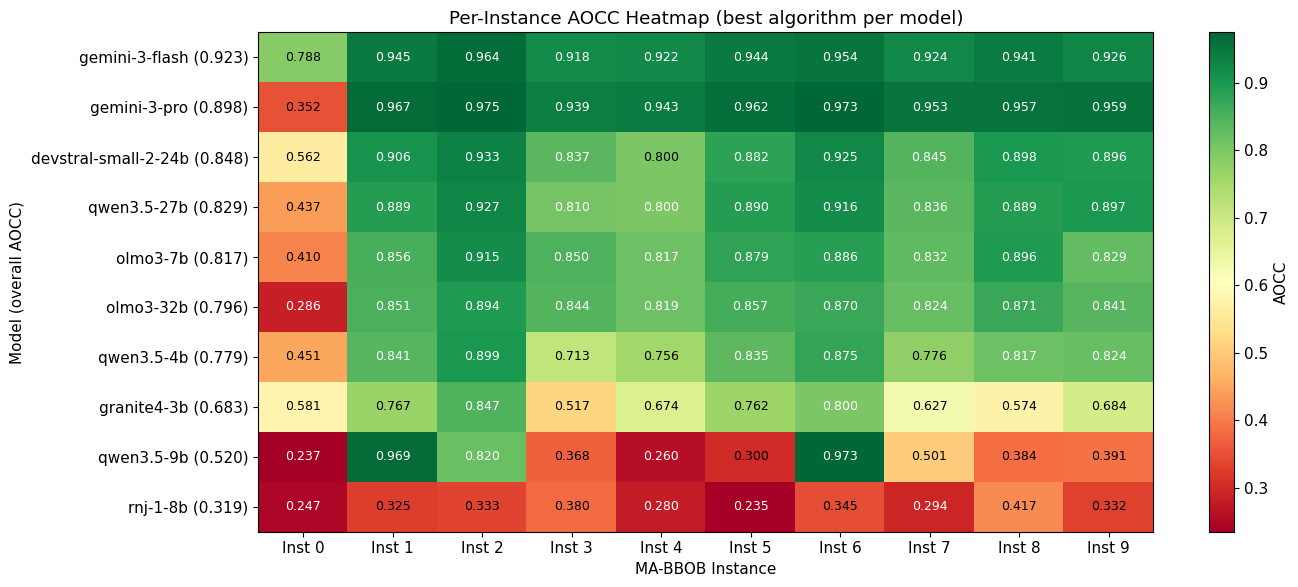


Mean AOCC per instance across models:
  Instance 0: 0.4351 (HARDEST)
  Instance 1: 0.8316 
  Instance 2: 0.8507 
  Instance 3: 0.7176 
  Instance 4: 0.7070 
  Instance 5: 0.7547 
  Instance 6: 0.8517 (EASIEST)
  Instance 7: 0.7411 
  Instance 8: 0.7644 
  Instance 9: 0.7579 


In [2]:
# --- Per-Instance Performance Heatmap ---
# Reshape 50 AUCs -> (10 instances x 5 eval seeds), take mean per instance

# Sort models by overall best AOCC
sorted_models = sorted(
    [m for m in MODELS if m in best_per_model],
    key=lambda m: best_per_model[m]["mean_aocc"],
    reverse=True,
)

instance_matrix = []
model_labels = []

for model in sorted_models:
    info = best_per_model[model]
    aucs = info["aucs"]
    if len(aucs) != N_INSTANCES * EVAL_SEEDS:
        # Pad or skip
        print(f"WARNING: {model} has {len(aucs)} AUCs, expected {N_INSTANCES * EVAL_SEEDS}")
        instance_means = np.full(N_INSTANCES, np.nan)
    else:
        # Reshape: (N_INSTANCES, EVAL_SEEDS)
        aucs_reshaped = aucs.reshape(N_INSTANCES, EVAL_SEEDS)
        instance_means = aucs_reshaped.mean(axis=1)
    instance_matrix.append(instance_means)
    model_labels.append(f"{model} ({info['mean_aocc']:.3f})")

instance_matrix = np.array(instance_matrix)

fig, ax = plt.subplots(figsize=(14, max(6, len(sorted_models) * 0.6)))
im = ax.imshow(instance_matrix, aspect="auto", cmap="RdYlGn")

# Text annotations
for i in range(instance_matrix.shape[0]):
    for j in range(instance_matrix.shape[1]):
        val = instance_matrix[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=9,
                    color="black" if 0.3 < val < 0.8 else "white")

ax.set_xticks(range(N_INSTANCES))
ax.set_xticklabels([f"Inst {i}" for i in range(N_INSTANCES)])
ax.set_yticks(range(len(model_labels)))
ax.set_yticklabels(model_labels)
ax.set_xlabel("MA-BBOB Instance")
ax.set_ylabel("Model (overall AOCC)")
ax.set_title("Per-Instance AOCC Heatmap (best algorithm per model)")
plt.colorbar(im, ax=ax, label="AOCC")
plt.tight_layout()
plt.savefig("phase1_instance_heatmap.pdf", bbox_inches="tight")
plt.show()

# Identify hard/easy instances
mean_per_instance = np.nanmean(instance_matrix, axis=0)
print("\nMean AOCC per instance across models:")
for i, m in enumerate(mean_per_instance):
    label = "(HARDEST)" if i == np.nanargmin(mean_per_instance) else \
            "(EASIEST)" if i == np.nanargmax(mean_per_instance) else ""
    print(f"  Instance {i}: {m:.4f} {label}")

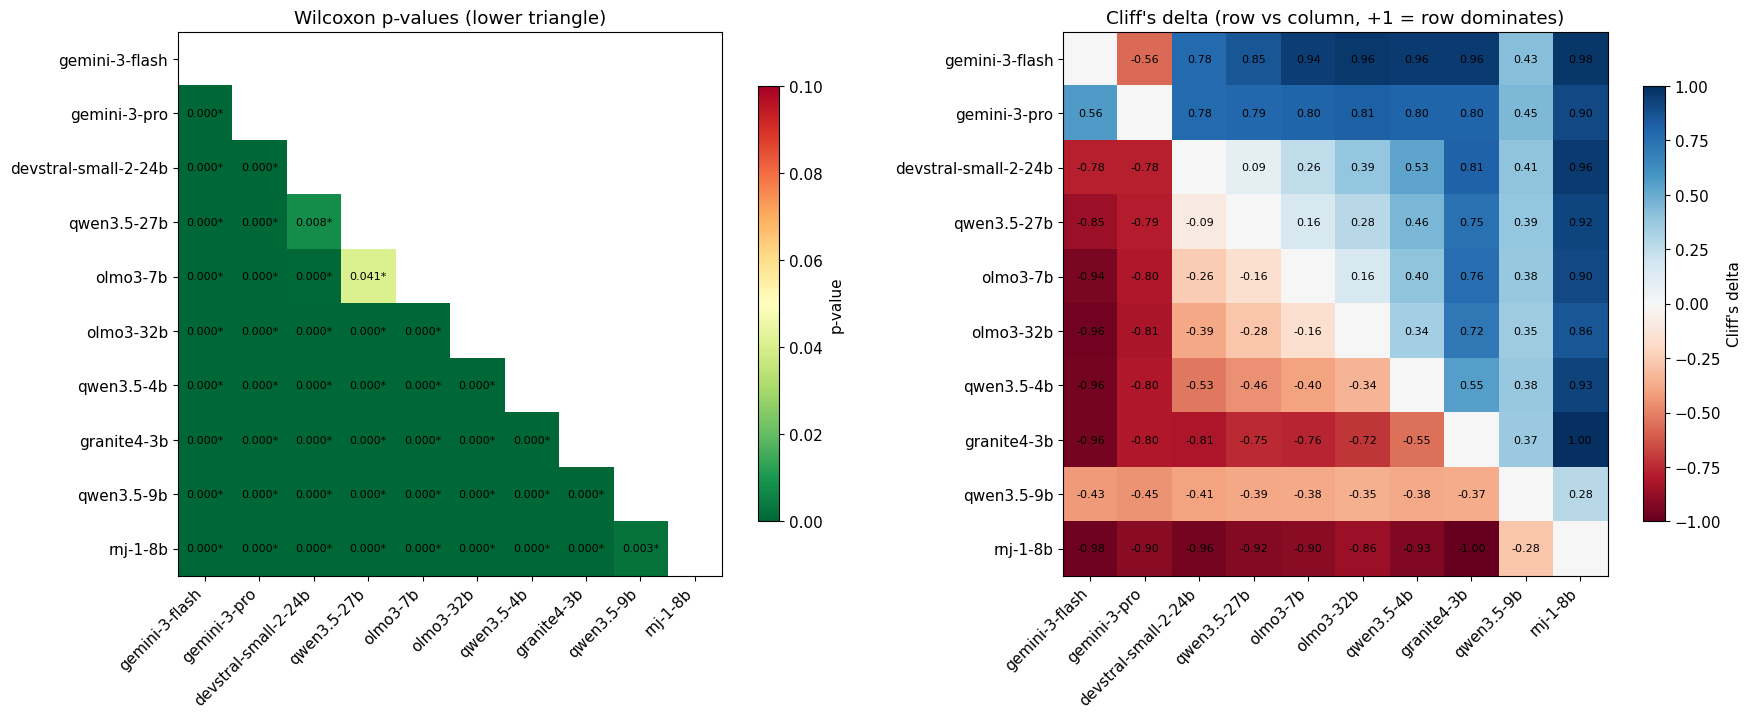


Win counts (row beat column on N of 50 paired AUCs):


,gemini-3-flash,gemini-3-pro,devstral-small-2-24b,qwen3.5-27b,olmo3-7b,olmo3-32b,qwen3.5-4b,granite4-3b,qwen3.5-9b,rnj-1-8b
gemini-3-flash,0,6,49,50,49,50,49,49,36,50
gemini-3-pro,44,0,46,47,48,49,47,45,40,50
devstral-small-2-24b,1,4,0,36,35,44,47,48,36,50
qwen3.5-27b,0,3,14,0,34,40,47,46,36,50
olmo3-7b,1,2,15,16,0,40,44,46,36,50
olmo3-32b,0,1,6,10,10,0,37,45,35,50
qwen3.5-4b,1,3,3,3,6,13,0,46,35,50
granite4-3b,1,5,2,4,4,5,4,0,34,49
qwen3.5-9b,14,10,14,14,14,15,15,16,0,28
rnj-1-8b,0,0,0,0,0,0,0,1,22,0


In [5]:
# --- Pairwise Algorithm Comparison ---

def cliffs_delta(x, y):
    n_x, n_y = len(x), len(y)
    more = sum(1 for xi in x for yi in y if xi > yi)
    less = sum(1 for xi in x for yi in y if xi < yi)
    return (more - less) / (n_x * n_y)


n_models = len(sorted_models)
pval_matrix = np.ones((n_models, n_models))
delta_matrix = np.zeros((n_models, n_models))
win_matrix = np.zeros((n_models, n_models), dtype=int)

for i in range(n_models):
    aucs_i = best_per_model[sorted_models[i]]["aucs"]
    for j in range(i + 1, n_models):
        aucs_j = best_per_model[sorted_models[j]]["aucs"]
        if len(aucs_i) == 0 or len(aucs_j) == 0:
            continue
        min_len = min(len(aucs_i), len(aucs_j))
        ai, aj = aucs_i[:min_len], aucs_j[:min_len]

        # Wilcoxon signed-rank test
        try:
            stat, p = stats.wilcoxon(ai, aj)
        except ValueError:
            p = 1.0
        pval_matrix[i, j] = p
        pval_matrix[j, i] = p

        # Cliff's delta
        d = cliffs_delta(ai, aj)
        delta_matrix[i, j] = d
        delta_matrix[j, i] = -d

        # Win/loss counts
        wins_i = int(np.sum(ai > aj))
        wins_j = int(np.sum(aj > ai))
        win_matrix[i, j] = wins_i
        win_matrix[j, i] = wins_j

# --- Combined heatmap: p-values (lower tri) + win counts (upper tri) ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

short_labels = sorted_models

# P-value heatmap
ax = axes[0]
mask = np.triu(np.ones_like(pval_matrix, dtype=bool), k=0)
pval_display = np.ma.masked_where(mask, pval_matrix)
im0 = ax.imshow(pval_display, cmap="RdYlGn_r", vmin=0, vmax=0.1)
for i in range(n_models):
    for j in range(i):
        val = pval_matrix[i, j]
        marker = "*" if val < 0.05 else ""
        ax.text(j, i, f"{val:.3f}{marker}", ha="center", va="center", fontsize=8)
ax.set_xticks(range(n_models))
ax.set_xticklabels(short_labels, rotation=45, ha="right")
ax.set_yticks(range(n_models))
ax.set_yticklabels(short_labels)
ax.set_title("Wilcoxon p-values (lower triangle)")
plt.colorbar(im0, ax=ax, label="p-value", shrink=0.8)

# Cliff's delta heatmap
ax = axes[1]
im1 = ax.imshow(delta_matrix, cmap="RdBu", vmin=-1, vmax=1)
for i in range(n_models):
    for j in range(n_models):
        if i == j:
            continue
        val = delta_matrix[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)
ax.set_xticks(range(n_models))
ax.set_xticklabels(short_labels, rotation=45, ha="right")
ax.set_yticks(range(n_models))
ax.set_yticklabels(short_labels)
ax.set_title("Cliff's delta (row vs column, +1 = row dominates)")
plt.colorbar(im1, ax=ax, label="Cliff's delta", shrink=0.8)

plt.tight_layout()
plt.savefig("phase1_pairwise_comparison.pdf", bbox_inches="tight")
plt.show()

# Print win matrix
print("\nWin counts (row beat column on N of 50 paired AUCs):")
df_wins = pd.DataFrame(win_matrix, index=short_labels, columns=short_labels)
display(df_wins)

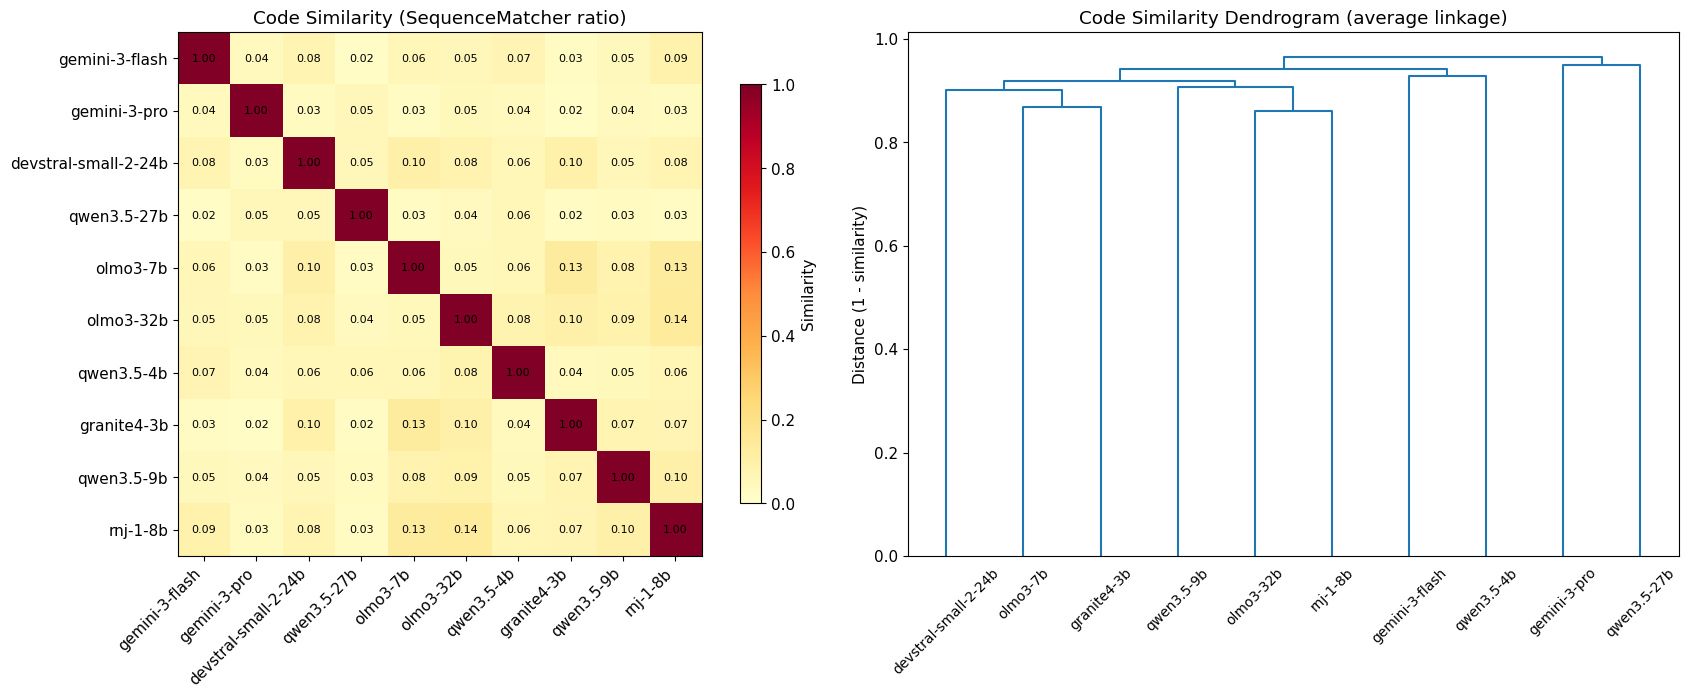


Pairwise diff statistics (unified_diff changed lines / total lines):
             gemini-3-flash vs gemini-3-pro             : sim=0.040  diff_ratio=1.653  changed_lines=443
             gemini-3-flash vs devstral-small-2-24b     : sim=0.078  diff_ratio=1.608  changed_lines=304
             gemini-3-flash vs qwen3.5-27b              : sim=0.017  diff_ratio=1.651  changed_lines=444
             gemini-3-flash vs olmo3-7b                 : sim=0.062  diff_ratio=1.222  changed_lines=231
             gemini-3-flash vs olmo3-32b                : sim=0.053  diff_ratio=1.323  changed_lines=250
             gemini-3-flash vs qwen3.5-4b               : sim=0.071  diff_ratio=1.471  changed_lines=278
             gemini-3-flash vs granite4-3b              : sim=0.025  diff_ratio=1.296  changed_lines=245
             gemini-3-flash vs qwen3.5-9b               : sim=0.047  diff_ratio=1.603  changed_lines=303
             gemini-3-flash vs rnj-1-8b                 : sim=0.088  diff_ratio=1.127  cha

In [6]:
# --- Code Similarity Analysis ---
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

n_models = len(sorted_models)
sim_matrix = np.zeros((n_models, n_models))

# Compute upper triangle only (symmetric)
for i in range(n_models):
    code_i = best_per_model[sorted_models[i]]["code"]
    sim_matrix[i, i] = 1.0
    for j in range(i + 1, n_models):
        code_j = best_per_model[sorted_models[j]]["code"]
        ratio = difflib.SequenceMatcher(None, code_i, code_j).ratio()
        sim_matrix[i, j] = ratio
        sim_matrix[j, i] = ratio

# --- Similarity heatmap ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
im = ax.imshow(sim_matrix, cmap="YlOrRd", vmin=0, vmax=1)
for i in range(n_models):
    for j in range(n_models):
        ax.text(j, i, f"{sim_matrix[i, j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_xticks(range(n_models))
ax.set_xticklabels(sorted_models, rotation=45, ha="right")
ax.set_yticks(range(n_models))
ax.set_yticklabels(sorted_models)
ax.set_title("Code Similarity (SequenceMatcher ratio)")
plt.colorbar(im, ax=ax, label="Similarity", shrink=0.8)

# --- Dendrogram ---
ax = axes[1]
dist_matrix = 1.0 - sim_matrix
np.fill_diagonal(dist_matrix, 0)  # ensure diagonal is exactly 0
condensed_dist = squareform(dist_matrix)
Z = linkage(condensed_dist, method="average")
dendrogram(Z, labels=sorted_models, ax=ax, leaf_rotation=45, leaf_font_size=10)
ax.set_title("Code Similarity Dendrogram (average linkage)")
ax.set_ylabel("Distance (1 - similarity)")

plt.tight_layout()
plt.savefig("phase1_code_similarity.pdf", bbox_inches="tight")
plt.show()

# --- Diff statistics ---
print("\nPairwise diff statistics (unified_diff changed lines / total lines):")
for i in range(n_models):
    code_i = best_per_model[sorted_models[i]]["code"].splitlines()
    for j in range(i + 1, n_models):
        code_j = best_per_model[sorted_models[j]]["code"].splitlines()
        diff = list(difflib.unified_diff(code_i, code_j, lineterm=""))
        changed = sum(1 for line in diff if line.startswith("+") or line.startswith("-"))
        total = max(len(code_i), len(code_j), 1)
        ratio = changed / total
        print(f"  {sorted_models[i]:>25s} vs {sorted_models[j]:<25s}: "
              f"sim={sim_matrix[i,j]:.3f}  diff_ratio={ratio:.3f}  "
              f"changed_lines={changed}")

# Summary
upper_sims = sim_matrix[np.triu_indices(n_models, k=1)]
print(f"\nOverall code similarity stats (N={len(upper_sims)} pairs):")
print(f"  Mean: {np.mean(upper_sims):.3f}")
print(f"  Std:  {np.std(upper_sims):.3f}")
print(f"  Min:  {np.min(upper_sims):.3f}")
print(f"  Max:  {np.max(upper_sims):.3f}")